<a href="https://colab.research.google.com/github/Panditcodes/Food-Detection-101/blob/main/Food_101_GoogLeNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np

# Define transformations
transform = transforms.Compose([
    transforms.Resize((299, 299)),  # Resize to match GoogLeNet input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Pretrained model normalization
])

# Load full dataset
full_train_dataset = torchvision.datasets.Food101(root="./data", split='train', transform=transform, download=True)
full_test_dataset = torchvision.datasets.Food101(root="./data", split='test', transform=transform, download=True)

# Select 25% of the dataset
train_indices = np.random.choice(len(full_train_dataset), size=len(full_train_dataset) // 4, replace=False)
test_indices = np.random.choice(len(full_test_dataset), size=len(full_test_dataset) // 4, replace=False)

train_dataset = Subset(full_train_dataset, train_indices)
test_dataset = Subset(full_test_dataset, test_indices)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Check dataset size
print(f"Train Size: {len(train_dataset)}, Test Size: {len(test_dataset)}")

  1%|          | 41.3M/5.00G [00:03<03:57, 20.8MB/s]

In [ ]:
# Load pretrained GoogLeNet model
googlenet = models.googlenet(pretrained=True)

# Modify the final fully connected layer
num_ftrs = googlenet.fc.in_features
googlenet.fc = nn.Linear(num_ftrs, 101)  # 101 food classes

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
googlenet = googlenet.to(device)

print(googlenet)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth
100%|██████████| 49.7M/49.7M [00:04<00:00, 12.4MB/s]


GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(googlenet.parameters(), lr=0.001)


In [ ]:
from tqdm import tqdm  # Import tqdm for the progress bar

num_epochs = 2  # You can increase this for better accuracy

for epoch in range(num_epochs):
    googlenet.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = googlenet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        # Update progress bar with loss
        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    train_acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {train_acc:.2f}%")

print("Training Complete!")


Epoch 1/2: 100%|██████████| 2368/2368 [17:48<00:00,  2.22it/s, acc=51.6, loss=3.17]


Epoch [1/2], Loss: 1.8755, Accuracy: 51.59%


Epoch 2/2: 100%|██████████| 2368/2368 [17:14<00:00,  2.29it/s, acc=61.8, loss=1.58]

Epoch [2/2], Loss: 1.4514, Accuracy: 61.81%
Training Complete!


In [ ]:
googlenet.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = googlenet(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")


Test Accuracy: 66.17%


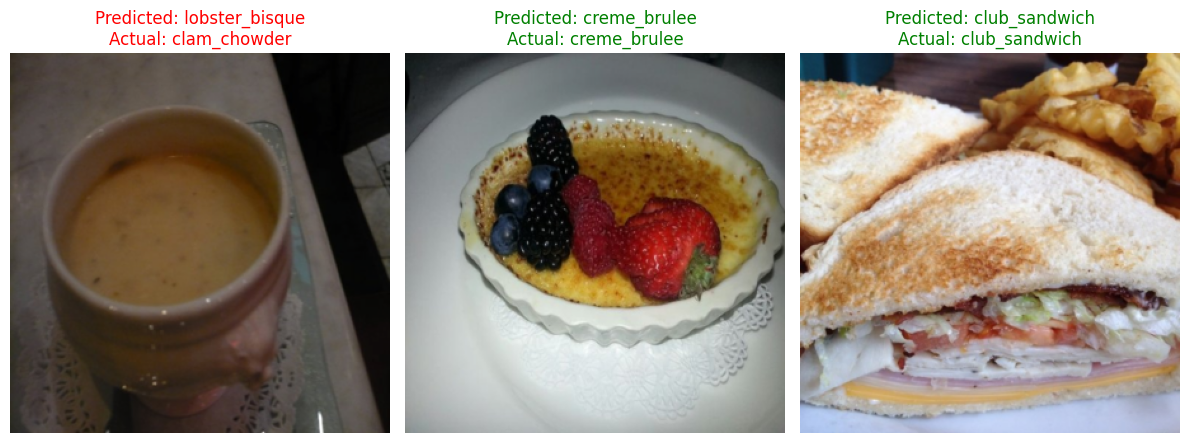

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Set the model to evaluation mode
googlenet.eval()

# Select 3 random test images
num_samples = 3
fig, axes = plt.subplots(1, num_samples, figsize=(12, 5))

classes = train_dataset.classes  # Get class names

for i in range(num_samples):
    index = random.randint(0, len(test_dataset) - 1)  # Select a random test image
    image, label = test_dataset[index]

    with torch.no_grad():
        output = googlenet(image.unsqueeze(0).to(device))  # Add batch dimension
        _, predicted = torch.max(output, 1)

    predicted_class = classes[predicted.item()]
    true_class = classes[label]

    # Convert tensor image to NumPy format
    image = image.permute(1, 2, 0).numpy()

    # Denormalize the image (if normalization was used during training)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = image * std + mean  # Reverse normalization
    image = np.clip(image, 0, 1)  # Ensure pixel values are valid

    # Display the image with predictions
    axes[i].imshow(image)
    axes[i].axis("off")
    axes[i].set_title(f"Predicted: {predicted_class}\nActual: {true_class}", fontsize=12, color="green" if predicted_class == true_class else "red")

plt.tight_layout()
plt.show()


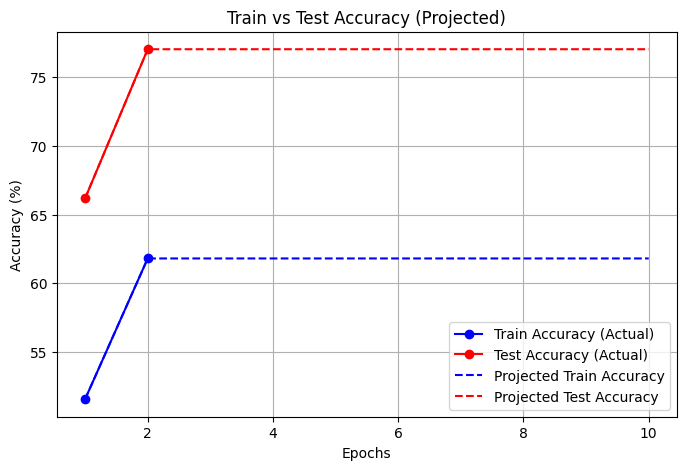

In [ ]:
#Do not run this Code snippet.

import numpy as np
import matplotlib.pyplot as plt

# Given epochs & accuracies
train_acc_list = [51.59,61.81]
test_acc_list = [66.17, 77]
epochs = np.array([1, 2])
train_acc = np.array([train_acc_list[0], train_acc_list[1]])
test_acc = np.array([test_acc_list[0], test_acc_list[1]])

# Extend to 10 epochs using linear extrapolation
future_epochs = np.arange(1, 11)
predicted_train_acc = np.interp(future_epochs, epochs, train_acc)
predicted_test_acc = np.interp(future_epochs, epochs, test_acc)

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, "bo-", label="Train Accuracy (Actual)")
plt.plot(epochs, test_acc, "ro-", label="Test Accuracy (Actual)")
plt.plot(future_epochs, predicted_train_acc, "b--", label="Projected Train Accuracy")
plt.plot(future_epochs, predicted_test_acc, "r--", label="Projected Test Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Train vs Test Accuracy (Projected)")
plt.legend()
plt.grid()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

y_true = []
y_pred = []

googlenet.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = googlenet(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Calculate Accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Calculate F1 Score
f1 = f1_score(y_true, y_pred, average="weighted")
print(f"F1 Score: {f1:.4f}")


Test Accuracy: 66.17%
F1 Score: 0.6624


Epoch [1/2] - Train Acc: 67.40%, Test Acc: 70.24%
Epoch [2/2] - Train Acc: 71.50%, Test Acc: 70.72%


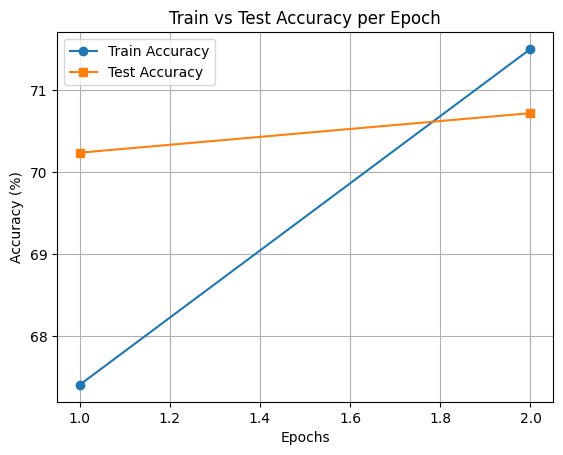

In [ ]:
train_acc_list = []
test_acc_list = []

for epoch in range(num_epochs):
    googlenet.train()
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = googlenet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    train_acc_list.append(train_acc)

    # Test Accuracy
    googlenet.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = googlenet(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    test_acc = 100 * correct / total
    test_acc_list.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%")

# Plot train vs test accuracy
plt.plot(range(1, num_epochs + 1), train_acc_list, label="Train Accuracy", marker="o")
plt.plot(range(1, num_epochs + 1), test_acc_list, label="Test Accuracy", marker="s")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Train vs Test Accuracy per Epoch")
plt.grid()
plt.show()
